In [ ]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    roc_auc_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.datasets import fetch_openml

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42

# Папка для артефактов
ARTIFACTS = Path("artifacts_pokemon")
ARTIFACTS.mkdir(exist_ok=True)

: 

In [ ]:
import sys
!{sys.executable} -m pip install matplotlib

In [53]:
#import sys
#!{sys.executable} -m pip install scikit-learn==1.6.1

In [54]:
pokemon = fetch_openml(data_id=43379, as_frame=True, parser="auto")
df = pokemon.frame.copy()

print("Размер:", df.shape)
df.head()

Размер: (801, 14)


,pokedex_number,name,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,1,Bulbasaur,49,49,0.7,45,88.1,65,65,45,grass,6.9,1,0
1,2,Ivysaur,62,63,1.0,60,88.1,80,80,60,grass,13.0,1,0
2,3,Venusaur,100,123,2.0,80,88.1,122,120,80,grass,100.0,1,0
3,4,Charmander,52,43,0.6,39,88.1,60,50,65,fire,8.5,1,0
4,5,Charmeleon,64,58,1.1,58,88.1,80,65,80,fire,19.0,1,0


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pokedex_number   801 non-null    int64  
 1   name             801 non-null    str    
 2   attack           801 non-null    int64  
 3   defense          801 non-null    int64  
 4   height_m         781 non-null    float64
 5   hp               801 non-null    int64  
 6   percentage_male  703 non-null    float64
 7   sp_attack        801 non-null    int64  
 8   sp_defense       801 non-null    int64  
 9   speed            801 non-null    int64  
 10  type             801 non-null    str    
 11  weight_kg        781 non-null    float64
 12  generation       801 non-null    int64  
 13  is_legendary     801 non-null    int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 87.7 KB


In [56]:
rate = df["is_legendary"].mean()
print(f"Легендарных покемонов: {int(df['is_legendary'].sum())} из {len(df)} ({rate:.1%})")
df["is_legendary"].value_counts()

Легендарных покемонов: 70 из 801 (8.7%)


is_legendary
0    731
1     70
Name: count, dtype: int64

In [57]:
DROP = ["pokedex_number", "name", "is_legendary"]
X = df.drop(columns=DROP)
y = df["is_legendary"]

In [58]:
numeric_cols = ["attack", "defense", "height_m", "hp", "speed", "sp_attack", "sp_defense", "weight_kg", "generation"]
# Все остальные колонки считаем категориальными
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("числовые:", numeric_cols)
print("категориальные:", categorical_cols)

числовые: ['attack', 'defense', 'height_m', 'hp', 'speed', 'sp_attack', 'sp_defense', 'weight_kg', 'generation']
категориальные: ['percentage_male', 'type']


In [59]:
print("Все колонки в датасете:")
print(df.columns.tolist())
print("\nПервые 3 строки:")
df.head(3)

Все колонки в датасете:
['pokedex_number', 'name', 'attack', 'defense', 'height_m', 'hp', 'percentage_male', 'sp_attack', 'sp_defense', 'speed', 'type', 'weight_kg', 'generation', 'is_legendary']

Первые 3 строки:


,pokedex_number,name,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,1,Bulbasaur,49,49,0.7,45,88.1,65,65,45,grass,6.9,1,0
1,2,Ivysaur,62,63,1.0,60,88.1,80,80,60,grass,13.0,1,0
2,3,Venusaur,100,123,2.0,80,88.1,122,120,80,grass,100.0,1,0


In [60]:
TARGET = "is_legendary"
DROP = ["pokedex_number", "name", TARGET]

X = df.drop(columns=DROP)
y = df[TARGET]

# Теперь мы точно знаем имена колонок
numeric_cols = ["attack", "defense", "height_m", "hp", "percentage_male", "sp_attack", "sp_defense", "speed", "weight_kg", "generation"]
categorical_cols = ["type"] # Остался только один категориальный признак!

print("Числовые:", numeric_cols)
print("Категориальные:", categorical_cols)

Числовые: ['attack', 'defense', 'height_m', 'hp', 'percentage_male', 'sp_attack', 'sp_defense', 'speed', 'weight_kg', 'generation']
Категориальные: ['type']


In [2]:
import sklearn

print(sklearn.__version__)


1.9.1


In [62]:
df.dtypes

pokedex_number       int64
name                   str
attack               int64
defense              int64
height_m           float64
hp                   int64
percentage_male    float64
sp_attack            int64
sp_defense           int64
speed                int64
type                   str
weight_kg          float64
generation           int64
is_legendary         int64
dtype: object

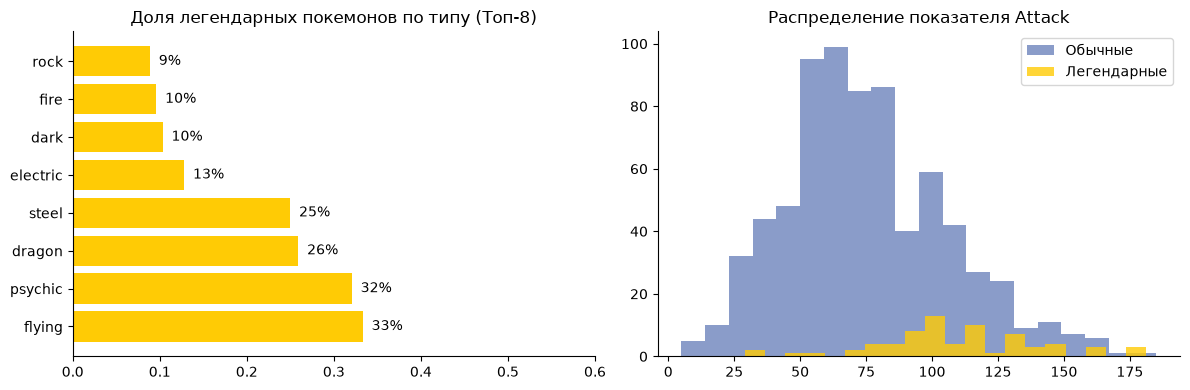

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Доля легендарных покемонов по типу (Топ-8)
by_type = df.groupby("type")["is_legendary"].mean().sort_values(ascending=False).head(8)

axes[0].barh(by_type.index, by_type.values, color="#FFCB05") # Pokemon yellow
axes[0].set_title("Доля легендарных покемонов по типу (Топ-8)")
axes[0].set_xlim(0, 0.6)
for i, v in enumerate(by_type.values):
    axes[0].text(v + 0.01, i, f"{v:.0%}", va="center")

# 2. Распределение показателя Attack для обычных и легендарных
axes[1].hist(df.loc[df.is_legendary == 0, "attack"], bins=20, alpha=0.6, label="Обычные", color="#3C5AA6") # Pokemon blue
axes[1].hist(df.loc[df.is_legendary == 1, "attack"], bins=20, alpha=0.8, label="Легендарные", color="#FFCB05")
axes[1].set_title("Распределение показателя Attack")
axes[1].legend()

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Размеры:", X_train.shape, X_test.shape)
print(f"Доля легендарных: train {y_train.mean():.3f}, test {y_test.mean():.3f}")

Размеры: (640, 11) (161, 11)
Доля легендарных: train 0.087, test 0.087


In [65]:
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols),
])

logreg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, C=1.0)),
])
logreg.fit(X_train, y_train)

def report(name, y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {
        "model": name,
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        f"precision@{threshold}": precision_score(y_true, pred, zero_division=0),
        f"recall@{threshold}": recall_score(y_true, pred, zero_division=0),
        f"F1@{threshold}": f1_score(y_true, pred, zero_division=0),
    }

proba_lr = logreg.predict_proba(X_test)[:, 1]
results = [report("logreg", y_test, proba_lr)]
pd.DataFrame(results).round(3)

,model,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,F1@0.5
0,logreg,0.967,0.758,0.7,0.5,0.583


In [66]:
from catboost import CatBoostClassifier

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

cat = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6,
    eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0,
)
cat.fit(
    X_tr, y_tr,
    cat_features=categorical_cols,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
)

print("лучшая итерация:", cat.get_best_iteration())
proba_cb = cat.predict_proba(X_test)[:, 1]
results.append(report("catboost", y_test, proba_cb))
pd.DataFrame(results).round(3)

лучшая итерация: 2


,model,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,F1@0.5
0,logreg,0.967,0.758,0.7,0.500,0.583
1,catboost,0.988,0.869,0.9,0.643,0.750


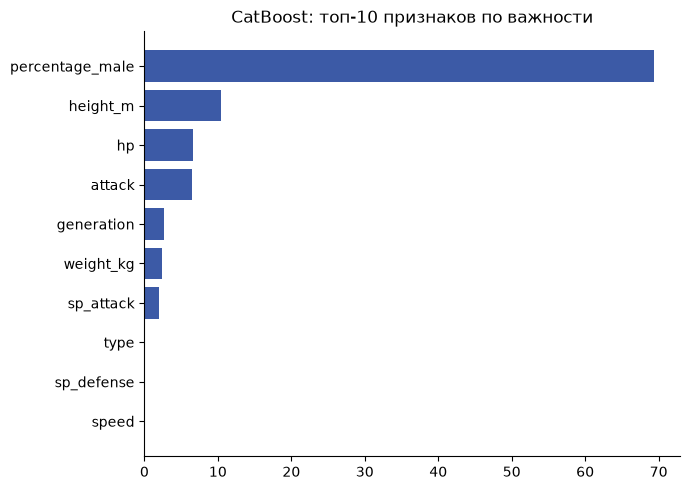

In [67]:
importances = pd.Series(cat.get_feature_importance(), index=X_tr.columns).sort_values()
plt.figure(figsize=(7, 5))
plt.barh(importances.index[-10:], importances.values[-10:], color="#3C5AA6")
plt.title("CatBoost: топ-10 признаков по важности")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

порог 0.501: recall 0.643, precision 0.900


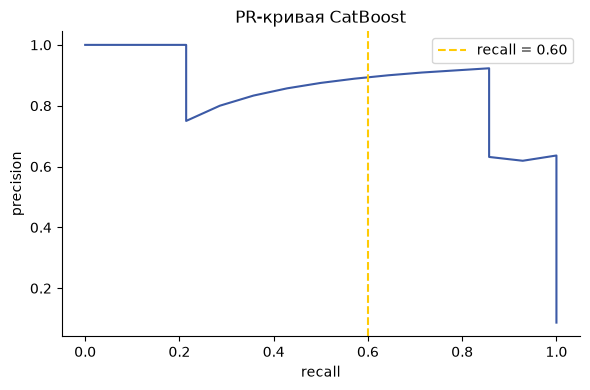

In [68]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_cb)
mask = recall[:-1] >= 0.60
best_threshold = thresholds[mask].max()
pred = (proba_cb >= best_threshold).astype(int)

print(f"порог {best_threshold:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="#3C5AA6")
plt.axvline(0.60, color="#FFCB05", linestyle="--", label="recall = 0.60")
plt.xlabel("recall"); plt.ylabel("precision"); plt.title("PR-кривая CatBoost")
plt.legend(); plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


In [69]:
import sklearn, catboost

metadata = {
    "model_name": "pokemon-legendary-predictor",
    "model_version": "0.1.0",
    "trained_at": pd.Timestamp.utcnow().isoformat(timespec="seconds"),
    "n_train": int(len(X_train)),
    "features": list(X.columns),
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "threshold": float(round(best_threshold, 4)),
    "metrics_test": {k: round(float(v), 4) for k, v in results[1].items() if k != "model"},
    "libs": {
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "catboost": catboost.__version__,
    },
}

joblib.dump(
    {"pipeline": logreg, "metadata": {**metadata, "model_name": "pokemon-logreg"}},
    ARTIFACTS / "pokemon_logreg.joblib",
)

cat.save_model(str(ARTIFACTS / "pokemon_catboost.cbm"))

(ARTIFACTS / "metadata.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8"
)

sorted(p.name for p in ARTIFACTS.iterdir())

['metadata.json', 'pokemon_catboost.cbm', 'pokemon_logreg.joblib']

In [70]:
ARTIFACTS

WindowsPath('artifacts_pokemon')

In [71]:
import os
print(os.getcwd())

C:\Users\User


In [72]:
bundle = joblib.load(ARTIFACTS / "pokemon_logreg.joblib")
pipe, meta = bundle["pipeline"], bundle["metadata"]

In [ ]:
# 1. Загружаем артефакт
bundle = joblib.load(ARTIFACTS / "pokemon_logreg.joblib")
pipe, meta = bundle["pipeline"], bundle["metadata"]

# 2. Берём реальную строку из теста — так мы гарантированно используем правильные колонки
# Это идеальная имитация того, как данные придут в API-сервис
payload = X_test.iloc[0].to_dict()

# 3. Превращаем обратно в DataFrame, строго соблюдая порядок колонок из метаданных
# Если в payload есть NaN (например, weight_kg), они останутся NaN — SimpleImputer внутри Pipeline их заполнит
frame = pd.DataFrame([payload])[meta["features"]]

# 4. Делаем предсказание
score = float(pipe.predict_proba(frame)[0, 1])

# 5. Выводим результат
print(json.dumps({
    "score": round(score, 4),
    "is_legendary_prediction": bool(score >= meta["threshold"]),
    "model_version": meta["model_version"],
}, ensure_ascii=False, indent=2))

# 6. Контроль: предсказание на одной строке должно совпадать с батчем
batch_score = float(pipe.predict_proba(X_test)[0, 1])
assert abs(batch_score - score) < 1e-9, "Ошибка: train-serve skew!"
print("\n✅ Успех: предсказание на одной строке и на батче совпадают до 1e-9")

{
  "score": 0.0055,
  "is_legendary_prediction": false,
  "model_version": "0.1.0"
}

✅ Успех: предсказание на одной строке и на батче совпадают до 1e-9


  Using cached scikit_learn-1.6.1.tar.gz (7.1 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): still running...
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [288 lines of output]
  + meson setup C:\Users\User\AppData\Local\Temp\pip-install-k81kkphl\scikit-learn_bf9e4d2596d142abba56beb8eecb2711 C:\Users\User\AppData\Local\Temp\pip-install-k81kkphl\scikit-learn_bf9e4d2596d142abba56beb8eecb2711\.mesonpy-h6fhzk7f -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\User\AppData\Local\Temp\pip-install-k81kkphl\scikit-learn_bf9e4d2596d142abba56beb8eecb2711\.mesonpy-h6fhzk7f\meson-python-native-file.ini
  The Meson build system
  Version: 1.12.1
  Source dir: C:\Users\User\AppData\Local\Temp\pip-install-k81kkphl\scikit-learn_bf9e4d2596d142abba56beb8eecb2711
  Build dir: C:\Users\User\AppData\Local\Temp\pip-install-k81kkphl\scikit-learn_bf9e4d2596d142abba56beb8eecb2711\.mesonpy-h6fhzk7f
  Build type: native build
  Activating VS 17.14.35 (June 2026)
  Project name: scikit-learn
  Project version: 1.6